<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/mse_logo.png" width="400" align="right"/>
<div style="text-align: left"> <b> Machine Learning FTP_MachLe </b> <br> HS 2026 <br> <a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

In [7]:
# imports
from IPython.display import Image, display
from IPython.display import HTML
import os
import requests
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# allow plots to appear directly in the notebook
%matplotlib inline

# raw URL of this repository on GitHub (images, data)
filepath = "https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main"

# **Feature Engineering – Group 3: Data Cleaning and Integration**

**Authors:** *Name 1, Name 2, Name 3, ...*

<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/images/03_Data_Clearning.png" width="1200"/>

## Introduction

**What is it about?**
Raw data is rarely ready for modelling. It contains missing entries (`np.nan`), noisy measurements, outliers caused by sensor faults or typos, and it is often spread over several tables or files. *Data cleaning* covers detecting and handling missing values (dropping, forward/backward fill, median imputation), smoothing noisy signals (e.g. moving averages), discretizing continuous values into bins, and detecting and removing outliers. *Data integration* combines several sources into one consistent dataset, typically by merging or joining pandas DataFrames on common keys.

**Where is it used?**
In practically every real project: sensor and IoT time series with gaps and spikes, medical records with incomplete measurements, business data from different databases (customers, orders, products), and survey data with unanswered questions. Tools of choice are `pandas` (`isna`, `fillna`, `ffill`, `rolling`, `cut`, `merge`) and `sklearn.impute`.

**Why is it important for Machine Learning?**
"Garbage in, garbage out": most scikit-learn estimators cannot handle `NaN` at all, and outliers or noise can strongly distort means, variances and fitted models. Practitioners often spend the majority of their time on data cleaning. Doing it carefully, and without leaking information from the test set (e.g. computing imputation statistics on the training data only), is a prerequisite for any trustworthy model.

## (i) Missing values and `np.nan`



In [8]:
# Create a 100-row dataset and insert missing values represented by np.nan
data_df = pd.DataFrame({
    "temperature": rng.normal(loc=20, scale=3, size=100),
    "humidity": rng.uniform(30, 70, size=100)
})

# Randomly set 10 values in each column to missing
for column in data_df.columns:
    missing_rows = rng.choice(data_df.index, size=10, replace=False)
    data_df.loc[missing_rows, column] = np.nan

# Check for missing values with np.nan
display(data_df.head())
print("Dataset shape:", data_df.shape)
print("Missing values per column:")
print(data_df.isna().sum())

,temperature,humidity
0,16.748904,60.400599
1,21.033815,NaN
2,21.137840,38.272541
3,23.861993,67.661554
4,23.299939,34.826213


Dataset shape: (100, 2)
Missing values per column:
temperature    10
humidity       10
dtype: int64


## (ii) Filtering and smoothing (moving averages)

### 1. Start with the problem: a noisy measurement
**How can we reduce noise without losing important signal details?**

Imagine a sensor recording 100 measurements per second. The orange line below contains measurement noise. The dashed line shows the underlying signal, which includes a step, a corner, and a short event.

Here, the underlying signal is known because we generated the data. With real measurements, it is usually unknown. A desired reference or setpoint is not necessarily the true measured motion.

**Look at the plot first:** Which fluctuations would you smooth out, and which changes should remain visible?

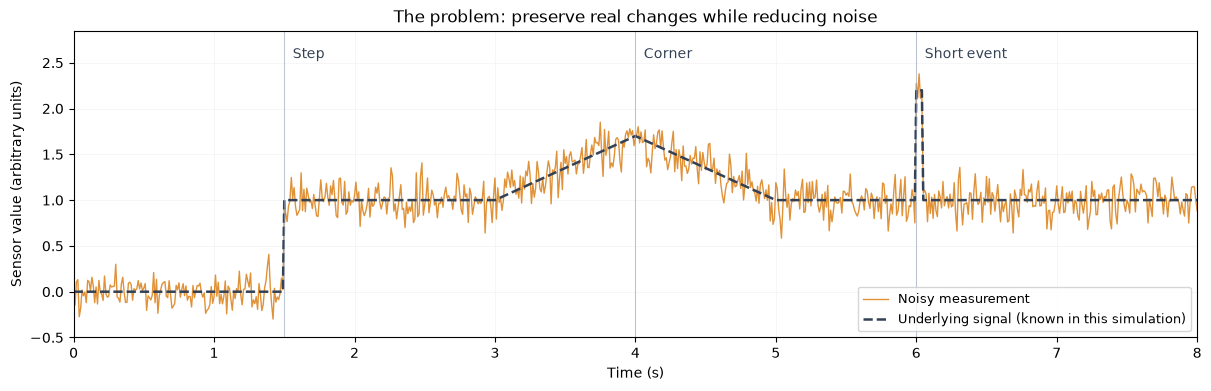

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Synthetic sensor data: the short event is real signal, not an outlier.
fs = 100  # observations per second
time_s = np.arange(801) / fs
rng = np.random.default_rng(42)
step = (time_s >= 1.5).astype(float)
triangle = 0.7 * np.maximum(1 - np.abs(time_s - 4.0), 0)
short_event = 1.2 * ((time_s >= 6.0) & (time_s < 6.05))
true_signal = step + triangle + short_event
signal_df = pd.DataFrame({
    'Time_s': time_s,
    'Underlying_signal': true_signal,
    'Measurement': true_signal + rng.normal(0, 0.14, len(time_s)),
})

fig, ax = plt.subplots(figsize=(12, 3.8), layout='constrained')
ax.plot(time_s, signal_df['Measurement'], color='#d97706', linewidth=1,
        alpha=0.8, label='Noisy measurement')
ax.plot(time_s, true_signal, color='#334155', linestyle='--', linewidth=1.8,
        label='Underlying signal (known in this simulation)')
for x, label in [(1.5, 'Step'), (4.0, 'Corner'), (6.0, 'Short event')]:
    ax.axvline(x, color='#94a3b8', linewidth=0.8, alpha=0.6)
    ax.text(x + 0.06, 2.55, label, fontsize=10, color='#334155')
ax.set(title='The problem: preserve real changes while reducing noise',
       xlabel='Time (s)', ylabel='Sensor value (arbitrary units)',
       xlim=(0, 8), ylim=(-0.5, 2.85))
ax.grid(alpha=0.15)
ax.legend(loc='lower right', fontsize=9)
plt.show()


### 2. The idea: average nearby measurements
A **simple moving average** replaces each value with the average of a group of nearby values. This group is the **window**. Every value inside it has the same weight.

For a window of 3, using the current and previous measurements:

| Measurements in the window | Calculation | Smoothed value |
|---|---|---:|
| **10, 12, 11**, 15, 13 | (10 + 12 + 11) / 3 | 11.00 |
| 10, **12, 11, 15**, 13 | (12 + 11 + 15) / 3 | 12.67 |
| 10, 12, **11, 15, 13** | (11 + 15 + 13) / 3 | 13.00 |

The window moves one observation forward each time. A single high or low measurement has less influence because it is averaged with its neighbours.

In pandas, `rolling(window=3)` creates the windows and `.mean()` calculates their averages. The original values remain in a separate column.


### 4. What do we learn?
- **Noise:** Larger windows reduce random fluctuations more strongly in this example.
- **Corners:** Sharp changes are rounded, so the shape is less accurately preserved.
- **Short events:** The brief pulse is a real event. A large window mixes it with many baseline values, reducing its height and spreading it over time.
- **Delay:** After the step, a trailing window still contains older, lower values. The average begins responding immediately, but takes longer to reach the new level when the window is larger.

**A smoother curve is not automatically a better representation of the data.**

### How should we choose the window size?
Start with the shortest real event you need to preserve and the sampling frequency. Our short event lasts **0.05 seconds**. A 31-observation window covers approximately **0.31 seconds**, so it strongly dilutes this event.

Compare several sizes and check both noise reduction and the preservation of meaningful changes. There is no universal best window. In an ML workflow, choose preprocessing settings using training/validation data, not the final test set.

### Practical limitations
- Sort observations by time. A window of 11 means **11 observations**, not automatically 11 seconds. The duration comparison above assumes regularly sampled data.
- `min_periods=window` leaves the first `window - 1` results as `NaN` because the full window is not yet available.
- A **centered** window uses neighbours on both sides. It does not have the same systematic lag as this trailing average, but still blurs details and needs future observations. It is suitable for retrospective analysis; it cannot produce the current result immediately in a live stream.
- When predicting the current measurement, exclude that measurement from the feature, for example with `shift(1)` before `rolling(...)`.
- Moving averages are sensitive to extreme values. Smoothing is not a replacement for outlier detection, and real short events should not automatically be treated as noise.

**Connection to data cleaning:** Smoothing prepares noisy measurements for analysis or machine learning while trying to preserve relevant information.

**Takeaway for the presentation:** "A larger window reduces noise more strongly, but can blur sharp changes and hide short events. A trailing moving average also introduces delay."

<details>
<summary>Optional: the formula behind the example</summary>

$$MA_t = rac{1}{w}sum_{j=0}^{w-1}x_{t-j}$$

Add the current and previous $w-1$ measurements, then divide by $w$.

</details>

**Reference:** [pandas: rolling](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html). All data, code, and figures in this section are synthetic examples created for this notebook.


## (iii) Binning and discretization



In [10]:
x

6.0

## (iv) Missing value imputation: forward/backward fill and median imputation



Imputation replaces missing values (`NaN`) with estimates. The right method depends on the feature’s meaning and whether observations have a meaningful order.

---

#### Some advanced filling techniques

* Most-frequent imputation
* KNN imputation - Use the neighbors to find a value
* KDE (Kernel density Estimation) - I use this for an Open Street Map Project. E.g. if you want to map pois to a grid cell and want to smooth the result e.g. 10m over the border still counts a little to the other cell.

#### 1. Forward Fill (`ffill`)

Replaces missing values with the last observed value: past → future.

Example: A device’s operating mode remains unchanged until a new mode is recorded.

| Time | Recorded mode | Forward-filled |
|------|---------------|----------------|
| 09:00 | Idle | Idle |
| 09:01 | NaN | Idle |
| 09:02 | Running | Running |
| 09:03 | NaN | Running |

```python
df["mode"] = df["mode"].ffill()
```

- Useful for persistent states or short gaps in slowly changing measurements.
- Can propagate stale values across long gaps.
- Leading missing values remain missing.
- Consider a gap limit to avoid filling long stretches.
- For forward/backward fill needs data preparation e.g. sort by time and fill separately for each entity/sensor/customer etc.

---

#### 2. Backward Fill (`bfill`)

Replaces missing values with the next observed value: future → past.

Example: A reporting system records each interval’s status at its end. Backward fill assigns that status to earlier rows within the interval—only if this matches the logging convention.

| Time | Recorded interval status | Backward-filled |
|------|--------------------------|-----------------|
| 09:01 | NaN | Normal |
| 09:02 | Normal | Normal |
| 09:03 | NaN | Warning |
| 09:04 | Warning | Warning |
| 09:05 | NaN | NaN |

```python
df["interval_status"] = df["interval_status"].bfill()
```

- Useful for retrospective processing when later values validly describe earlier gaps.
- Can cause look-ahead leakage in forecasting or real-time prediction.
- Trailing missing values remain missing.
- Consider a gap limit to avoid filling long stretches.
- For forward/backward fill needs data preparation e.g. sort by time and fill separately for each entity/sensor/customer etc.

---

#### 3. Median Imputation

Replaces missing numerical values with the feature’s training-set median.

Example: Missing apartment sizes are replaced with the median observed training size. An unusually large apartment has limited influence on the estimate.

**Avoid data leakage:** Learn imputation statistics only from training data, and reuse them for validation/test data. For time-dependent predictions, use only information available at prediction time.

```text
Training values: [40, 50, NaN, 60, 70, 300]
Median:          60
Imputed values:[40][50][60][70][300]

Test values:     [NaN, 80]
Imputed values:    ← reuse the training median[60, 80]
```

```python
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
```
- Useful as a simple baseline for numerical tabular features.
- Less sensitive to outliers than mean imputation.
- Creates a concentration at the median and can distort variance and feature relationships.


## (v) Outlier detection and removal



Concrete Core Samples with Structural Locations (first 10 rows):


,Sample_ID,Block,Storey,Compression_Strength_MPa
0,Core_01,Block A,Storey 1,43.403018
1,Core_02,Block A,Storey 1,33.967111
2,Core_03,Block A,Storey 1,45.738314
3,Core_04,Block A,Storey 2,42.337578
4,Core_05,Block A,Storey 2,78.200000
5,Core_06,Block A,Storey 2,38.840581
6,Core_07,Block A,Storey 2,37.249519
7,Core_08,Block A,Storey 3,38.404548
8,Core_09,Block A,Storey 3,40.666237
9,Core_10,Block A,Storey 3,38.424631



Sample counts per Block and Storey:


,Block,Storey,Sample_Count
0,Block A,Storey 1,3
1,Block A,Storey 2,4
2,Block A,Storey 3,3
3,Block B,Storey 1,3
4,Block B,Storey 2,3
5,Block B,Storey 3,4
6,Block C,Storey 1,3
7,Block C,Storey 2,3
8,Block C,Storey 3,6



IQR Outlier Thresholds: Lower Bound = 32.26 MPa, Upper Bound = 46.46 MPa
Detected Outliers:


,Sample_ID,Block,Storey,Compression_Strength_MPa
4,Core_05,Block A,Storey 2,78.2
26,Core_27,Block C,Storey 3,15.0
31,Core_32,Block C,Storey 3,12.5


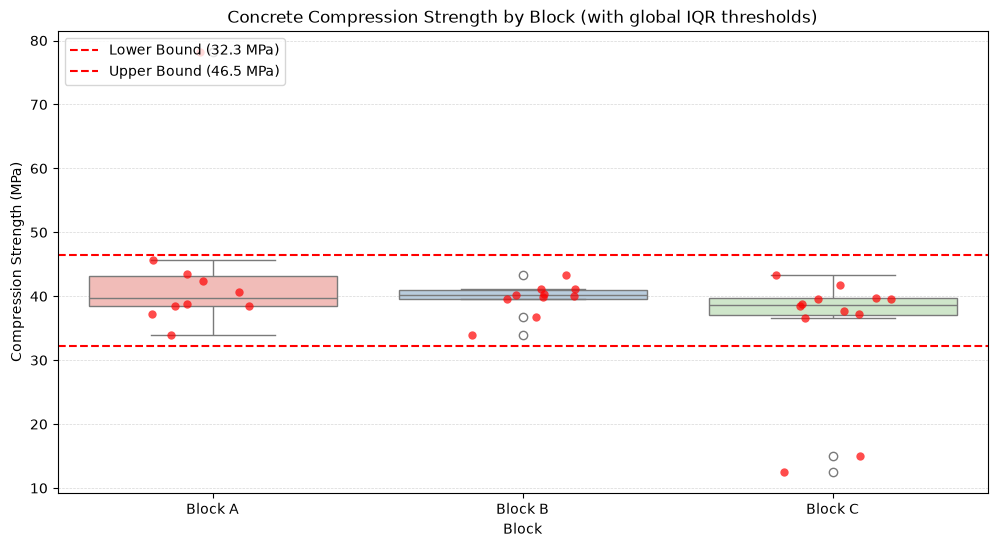

In [11]:
# 1. Generate structured concrete core data with Block and Storey information
# We will distribute 32 samples across Blocks and Storeys ensuring at least 3 samples per storey.
# Normally we have this data from compression tests :))
np.random.seed(42)

# Create structural metadata
blocks = ['Block A', 'Block B', 'Block C']
storeys = ['Storey 1', 'Storey 2', 'Storey 3']

records = []
sample_counter = 1

# Populate with at least 3 samples per storey per block
for block in blocks:
    for storey in storeys:
        # Generate 3 to 4 samples per storey
        num_samples_in_storey = np.random.choice([3, 4])
        for _ in range(num_samples_in_storey):
            if sample_counter <= 32:
                records.append({
                    'Sample_ID': f"Core_{sample_counter:02d}",
                    'Block': block,
                    'Storey': storey
                })
                sample_counter += 1

# If we still need to reach exactly 32 samples
while len(records) < 32:
    records.append({
        'Sample_ID': f"Core_{len(records)+1:02d}",
        'Block': 'Block C',
        'Storey': 'Storey 3'
    })

df_concrete = pd.DataFrame(records)

# Generate strength values with outliers
normal_strengths = np.random.normal(loc=40.0, scale=3.0, size=29)
outliers = np.array([12.5, 78.2, 15.0])
compression_strengths = np.concatenate([normal_strengths, outliers])
np.random.shuffle(compression_strengths)

df_concrete['Compression_Strength_MPa'] = compression_strengths

print("Concrete Core Samples with Structural Locations (first 10 rows):")
display(df_concrete.head(10))

# Verify minimum sample constraint per storey
print("\nSample counts per Block and Storey:")
display(df_concrete.groupby(['Block', 'Storey']).size().reset_index(name='Sample_Count'))

# 2. Outlier Detection using the Interquartile Range (IQR) method
Q1 = df_concrete['Compression_Strength_MPa'].quantile(0.25)
Q3 = df_concrete['Compression_Strength_MPa'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_detected = df_concrete[
    (df_concrete['Compression_Strength_MPa'] < lower_bound) |
    (df_concrete['Compression_Strength_MPa'] > upper_bound)
]

print(f"\nIQR Outlier Thresholds: Lower Bound = {lower_bound:.2f} MPa, Upper Bound = {upper_bound:.2f} MPa")
print("Detected Outliers:")
display(outliers_detected)

# 3. Outlier Removal
df_cleaned = df_concrete[
    (df_concrete['Compression_Strength_MPa'] >= lower_bound) &
    (df_concrete['Compression_Strength_MPa'] <= upper_bound)
]

# 4. Visualization: Boxplot grouped by Block with points overlaid
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_concrete, x='Block', y='Compression_Strength_MPa', palette='Pastel1', hue='Block', legend=False)
sns.stripplot(data=df_concrete, x='Block', y='Compression_Strength_MPa', color='red', size=6, jitter=0.2, alpha=0.7)
plt.axhline(lower_bound, color='red', linestyle='--', label=f'Lower Bound ({lower_bound:.1f} MPa)')
plt.axhline(upper_bound, color='red', linestyle='--', label=f'Upper Bound ({upper_bound:.1f} MPa)')
plt.title('Concrete Compression Strength by Block (with global IQR thresholds)')
plt.ylabel('Compression Strength (MPa)')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## (vi) Data integration: merging pandas DataFrames

Often you need to merge different data sources. There you have to deal with different unit of mesurement, duplicates and different index (daily vs. weekly) etc.

```python
import pandas as pd

customers = pd.DataFrame({
    "customer_id": [1, 2, 3],
    "name": ["Alice", "Bob", "Charlie"],
})

orders = pd.DataFrame({
    "customer_id": [1, 1, 2],
    "product": ["Laptop", "Mouse", "Keyboard"],
})

# Keep every customer and attach matching orders.
merged = customers.merge(orders, on="customer_id", how="left")
```

```
   customer_id     name   product
0            1    Alice    Laptop
1            1    Alice     Mouse
2            2      Bob  Keyboard
3            3  Charlie       NaN
```

## Takeaways

- **What should every ML practitioner remember?**
  - ...
- **What are common pitfalls?**
  - ...
- **When does this technique really matter?**
  - ...

## References

*Cite the sources of all figures, diagrams and code snippets (URLs are sufficient).*

1. ...